In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = '1305_night'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(2e3)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [3]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)

display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.009707,1785.063477,0.007000,0.032111,0.000000,0.000042
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.009707,1785.366211,0.007000,0.032111,0.000042,0.000042
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.009707,1785.670776,0.007000,0.032111,0.000084,0.000042
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.009707,1785.975342,0.007000,0.032112,0.000127,0.000042
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.009707,1786.280151,0.007000,0.032112,0.000169,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...
209564,124,5.00,0.0,24.891078,0.000000,0.233333,0.192620,4690.878418,0.009318,0.023301,0.291108,0.000541
209565,124,5.00,0.0,24.891078,0.000000,0.231944,0.192629,4627.829590,0.009670,0.023302,0.291649,0.000541
209566,124,5.00,0.0,24.891078,0.000000,0.230556,0.192637,4564.943359,0.010054,0.023303,0.292190,0.000541
209567,124,5.00,0.0,24.891078,0.000000,0.229167,0.192645,4502.242188,0.010466,0.023304,0.292731,0.000541


In [4]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [5]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


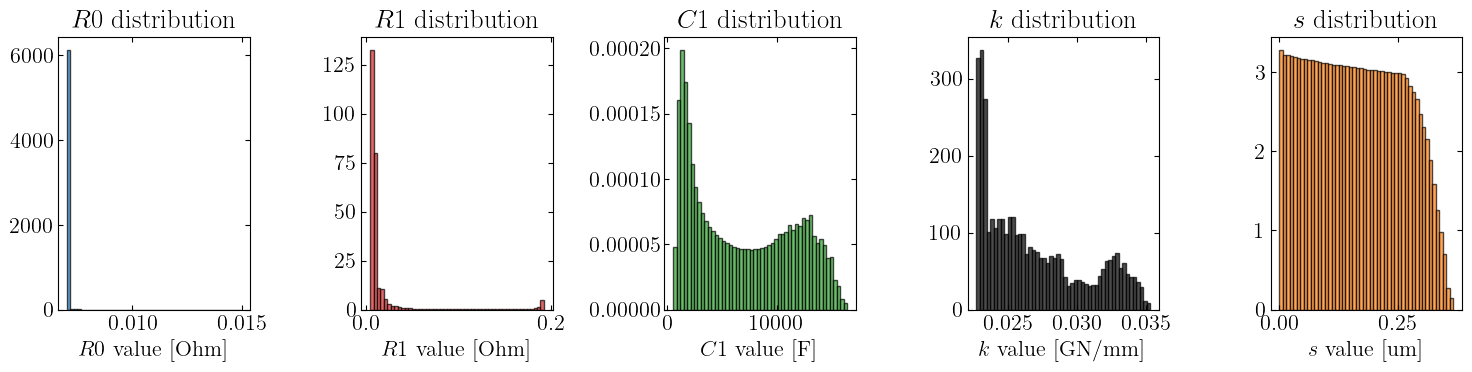

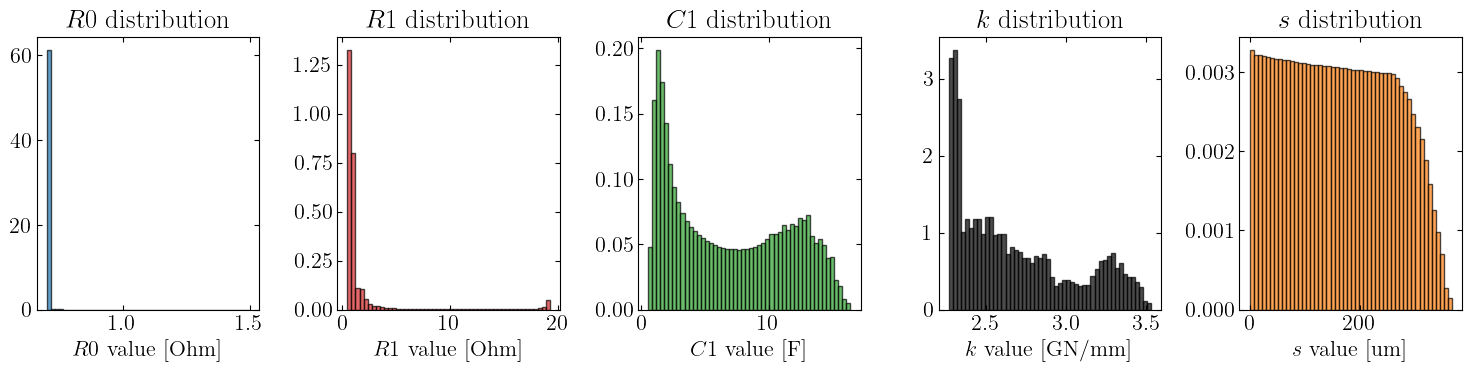

In [6]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [7]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [8]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 4th data point for symbolic regression, total points: 48455
Using every 1th data point for symbolic regression, total points: 15749


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id R0_1305_night...
Settings: iterations=2000, populations=100, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.0039349706
Equation: 0.70747024

Model 1: Complexity=5, Loss=0.0031543414
Equation: 0.68140054 - (-0.008699833 / x2)

Model 2: Complexity=6, Loss=0.0029277087
Equation: 0.6988811 - (-0.00044597665 / square(x2))

Model 3: Complexity=7, Loss=0.002923036
Equation: square(square(0.0157854 / x2) + 0.83633006)

Model 4: Complexity=8, Loss=0.001736801
Equation: 0.7041356 - (exp(x0 / x2) * -1.4716511e-10)

Model 5: Complexity=9, Loss=0.00049298775
Equation: 0.6988811 - cube(cube((x0 / x2) * -0.04365403))

Model 6: Complexity=11, Loss=0.0004686761
Equation: square(cube(((x0 / x2) * -0.06344304) - -0.45270413)) + 0.6981499

Model 7: Complexity=12, Loss=0.00041419905
Equation: log(cube(cube(-0.34299543 - ((-0.0650883 / x2) * x0))) + 2.0127642)

Model 8: Complexity=13, Loss=0.00034710506
Equation: square(cube(sin(cube((x0 / x2) * 0.04930991)))) + 0.6997534

Model 9: Complexity=14, Loss=0.00033274537
Equation: cube(cube(square(square(sin((x0 * -0.06579789) / x2))))) + 

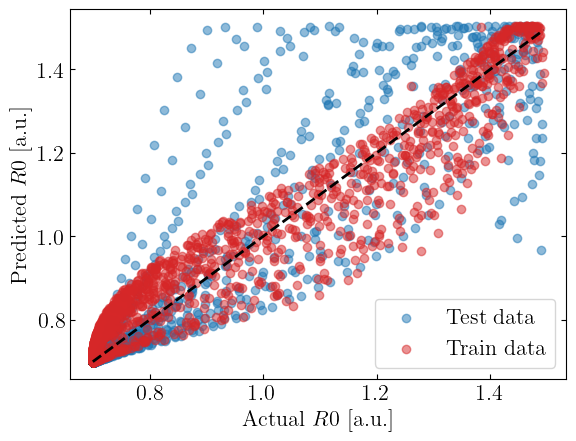

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.804130503952734*sin((x0*0.048193265/x2)**(3*x0))**3 + 0.69932395
Loss: 0.00017165701
Best model complexity: 17


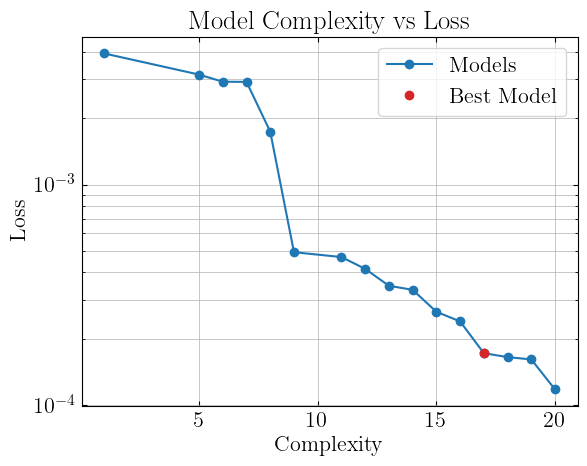

In [9]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id R1_1305_night...
Settings: iterations=2000, populations=100, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=10.8001585
Equation: 1.7103744

Model 1: Complexity=3, Loss=6.288519
Equation: 0.61812127 / x2

Model 2: Complexity=5, Loss=3.977912
Equation: square(log(x2)) * x0

Model 3: Complexity=6, Loss=1.4689461
Equation: cube((x0 * 0.13413872) / x2)

Model 4: Complexity=8, Loss=1.0682644
Equation: (0.0022673546 * cube(x0 / x2)) + 0.66738784

Model 5: Complexity=10, Loss=0.92020965
Equation: 0.12206828 / (exp(x0 * (-0.32055673 / x2)) + 0.004731309)

Model 6: Complexity=11, Loss=0.39517948
Equation: 0.79722464 / (exp(cube((x0 * -0.097570136) / x2)) + 0.04064129)

Model 7: Complexity=12, Loss=0.35802376
Equation: sqrt(0.6470754 / (exp(cube((-0.1150915 / x2) * x0)) + 0.0017931083))

Model 8: Complexity=13, Loss=0.32930222
Equation: 0.79116386 / (exp(cube(((x0 + 0.09433324) * -0.09325508) / x2)) + 0.040802248)

Model 9: Complexity=14, Loss=0.28015894
Equation: 0.9012846 / (sqrt(exp(cube((x0 * -0.12671992) / x2)) * x0) + 0.0467667)

Model 10: Complexity=15, Loss=0.1796675

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.86858505/(exp((x0*(-0.063220106) + x2 - 1*1.0493355)**27) + 0.043980718)
Loss: 0.17966759
Best model complexity: 15


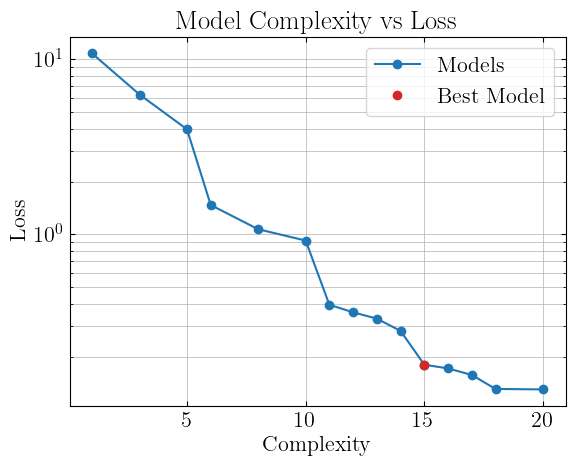

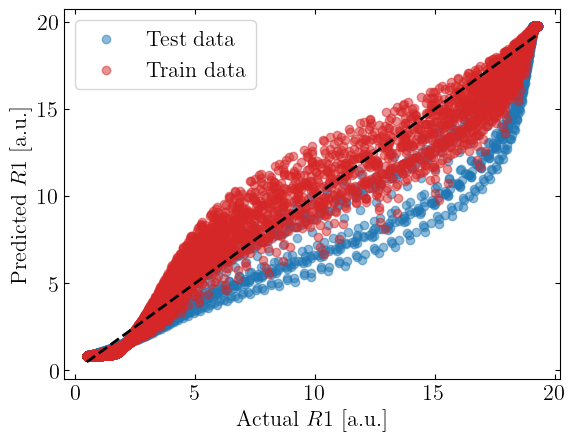

In [10]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Running symbolic regression for element None with run_id C1_1305_night...
Settings: iterations=2000, populations=100, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=21.86521
Equation: 6.860352

Model 1: Complexity=3, Loss=20.79475
Equation: 7.396906 - x2

Model 2: Complexity=4, Loss=18.296797
Equation: square(x2 - 3.1568222)

Model 3: Complexity=5, Loss=12.975235
Equation: cube(2.1404662 - cube(x2))

Model 4: Complexity=6, Loss=8.971938
Equation: (square(x2) - x2) * -40.93037

Model 5: Complexity=7, Loss=1.7097039
Equation: x2 / (square(cube(x2)) - -0.02581358)

Model 6: Complexity=8, Loss=1.3060371
Equation: square(x2 / (-0.07972543 - square(square(x2))))

Model 7: Complexity=9, Loss=1.2704217
Equation: (x2 + -0.059460975) / (square(cube(x2)) + 0.020133434)

Model 8: Complexity=10, Loss=1.1656092
Equation: (x2 / (square(square(x2)) - -0.07109127)) ^ 1.8694184

Model 9: Complexity=12, Loss=1.1178428
Equation: square(cube((2.2415345 / (x2 ^ x2)) + -1.7420118) + x2)

Model 10: Complexity=13, Loss=1.0683436
Equation: ((x0 / (x2 ^ 10.549151)) ^ x2) / (x0 - -2.476658)

Model 11: Complexity=15, Loss=0.879469
Equation: ((x0 / 

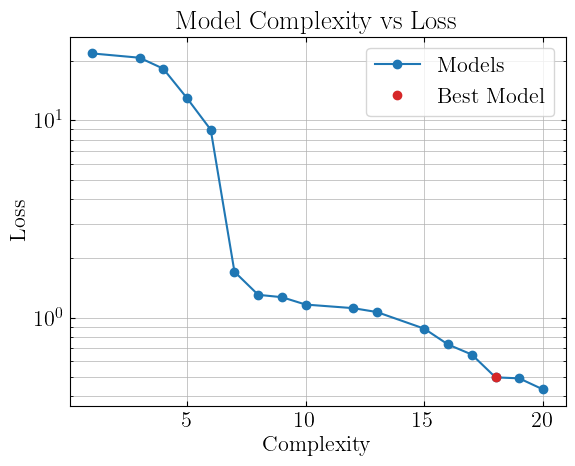

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x2 + (x0*1.6456604/x2**13.377182)**x2/(x0**2 - 1*(-10.526133))
Loss: 0.49837458
Best model complexity: 18


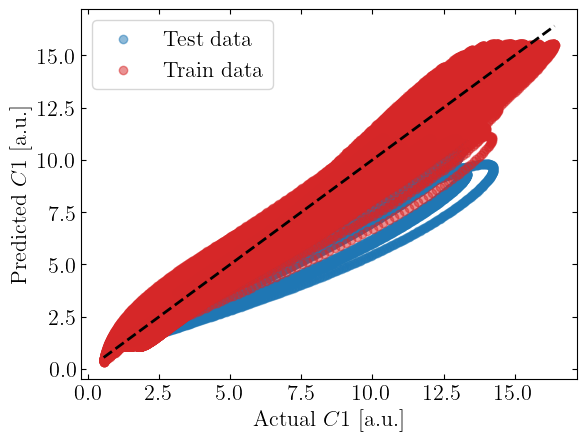

In [11]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id k_1305_night...
Settings: iterations=2000, populations=100, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.13329796
Equation: 2.6882355

Model 1: Complexity=4, Loss=0.07467854
Equation: log(x1 + 7.4520884)

Model 2: Complexity=5, Loss=0.003195667
Equation: (x1 * 0.03728228) - -2.25074

Model 3: Complexity=6, Loss=0.0010637922
Equation: (1.0262196 ^ x1) + 1.2892199

Model 4: Complexity=8, Loss=0.0009803523
Equation: ((1.0329385 ^ x1) + 2.1979485) * 0.7193925

Model 5: Complexity=9, Loss=0.0009734565
Equation: log(((1.0734398 ^ x1) + 2.3384032) * 2.997733)

Model 6: Complexity=10, Loss=0.00014713187
Equation: ((1.0262196 ^ x1) + 1.349769) + (x2 * -0.11269906)

Model 7: Complexity=11, Loss=9.195951e-05
Equation: ((0.9200431 ^ x2) * (1.02705 ^ x1)) + 1.3347703

Model 8: Complexity=12, Loss=9.175279e-05
Equation: ((0.9203497 ^ x2) * sqrt(1.0548475 ^ x1)) + 1.3342905

Model 9: Complexity=13, Loss=3.3166212e-05
Equation: ((0.9698987 ^ x2) + -0.25106487) * ((1.0324441 ^ x1) + 2.1415052)

Model 10: Complexity=14, Loss=2.5381249e-05
Equation: sqrt((x2 * -0.56888354) + sq

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -0.13738772*x2 + (1.235928**x1 + 0.71318257*x2)**(1/8) + 1.3368936
Loss: 4.5563447e-06
Best model complexity: 17


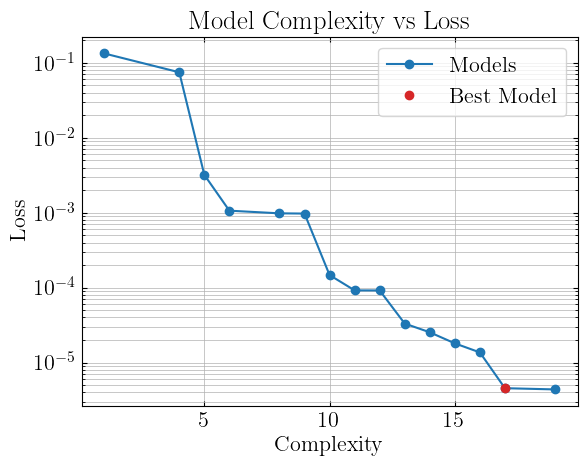

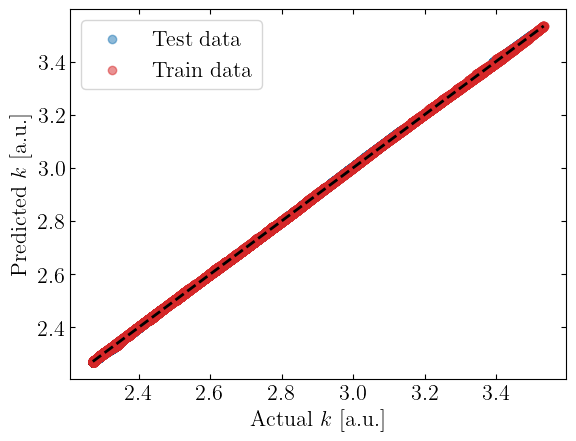

In [12]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

Running symbolic regression for element None with run_id s_1305_night...
Settings: iterations=2000, populations=100, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.009704461
Equation: 0.16602978

Model 1: Complexity=3, Loss=0.00012289156
Equation: x0 * 0.099671535

Model 2: Complexity=5, Loss=0.00010260243
Equation: x0 / (x2 + 9.478425)

Model 3: Complexity=6, Loss=2.4704423e-05
Equation: x0 / sqrt(x1 + 89.276855)

Model 4: Complexity=7, Loss=2.4657716e-05
Equation: (x0 / (x1 + 179.54294)) * 19.04284

Model 5: Complexity=8, Loss=6.3348457e-06
Equation: x0 / (sqrt(x1 + 78.622986) + x2)

Model 6: Complexity=10, Loss=5.7208345e-06
Equation: x0 / (sqrt((x1 + 81.3353) - x0) + x2)

Model 7: Complexity=11, Loss=4.3425375e-06
Equation: ((0.6199041 / ((x1 * x2) + 19.481451)) + 0.07461661) * x0

Model 8: Complexity=12, Loss=3.4808827e-06
Equation: x0 * ((sqrt(x2 * (x1 + x2)) * -0.0041104285) + 0.10909754)

Model 9: Complexity=13, Loss=3.4170823e-06
Equation: ((1.3208095 / (((x2 - -0.13612753) * x1) + 33.459538)) + 0.06706023) * x0

Model 10: Complexity=14, Loss=2.5259237e-06
Equation: (x0 / ((exp(x2) * (x1 * 0.08004504)) + (x2

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: x0*(0.061327774 + 2.512332/((x1 + 5.7046165)*(x2 + 0.3779144) + 50.42287))
Loss: 1.7261746e-06
Best model complexity: 15


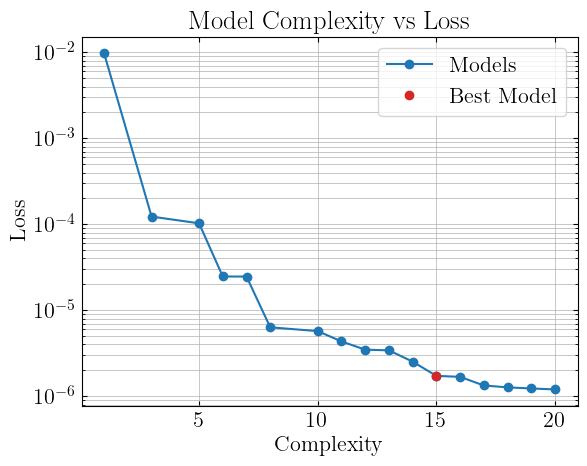

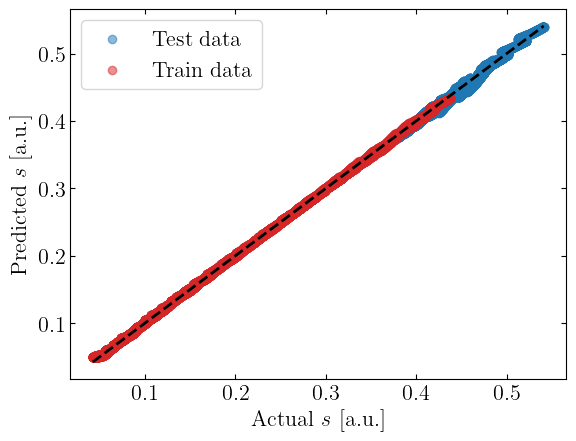

In [13]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s, s = True)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [14]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [15]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

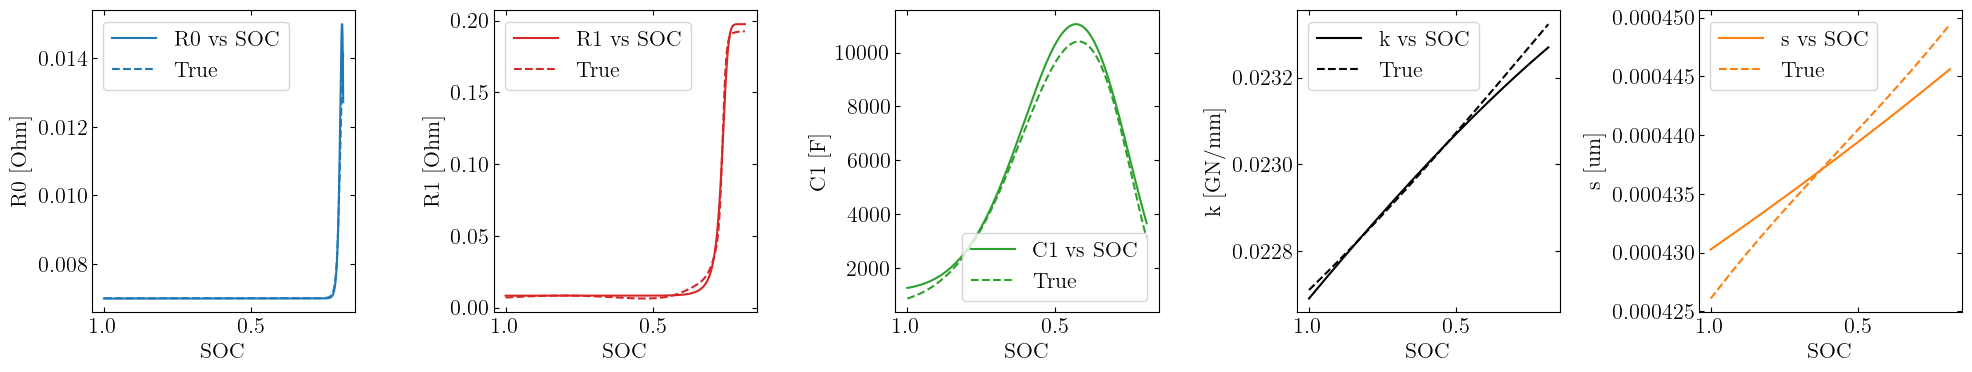

In [16]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        if var == 's':
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
            Y_true = traj['sdot']
        else:
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
            Y_true = traj[var]
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 1, test = True)
plot_soc(MODEL_DICT, traj)

In [17]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [18]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')